WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


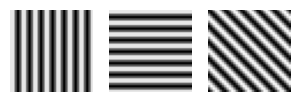

In [1]:
from pathlib import Path
import joblib
from insilico_stimuli.stimuli import GaborSet, CenterSurround
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models.hierarchical_grating_model import HierarchicalGratingModel
from sklearn.metrics.pairwise import cosine_similarity

canvas_size                = [36, 36]
locations                  = [[18, 18]]  # center position
sizes_total                = [36]          # total size (center + surround)
sizes_center               = [0.5]           # portion of radius used for center circle
sizes_surround             = [0.5]      # defines the starting portion of radius for surround
contrasts_center           = [1.0]     # try 2 center contrasts
contrasts_surround         = [1.0]          # surround contrast
orientations_center        = [0.0, np.pi/2, np.pi/4]  # variable orientation
orientations_surround      = [0.0, np.pi/2, np.pi/4]  # center only
spatial_frequencies_center = [0.2]           # fixed spatial frequency
phases_center              = [np.pi]  # center phases 
grey_levels                = [0.0]           # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(canvas_size=canvas_size, 
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=orientations_center,
        orientations_surround=orientations_surround,
        spatial_frequencies_center=spatial_frequencies_center,
        phases_center=phases_center,
        grey_levels=grey_levels
)

# gratings_offset = 0.5
gratings = np.array([center_surround.images()[idx] for idx in range(len(center_surround.images())) if center_surround.params_dict_from_idx(idx)['orientation_center'] == center_surround.params_dict_from_idx(idx)['orientation_surround']])
plt.figure(figsize=(10, 5))
for i, img in enumerate(gratings):
        plt.subplot(4, 8, i + 1)
        plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
        plt.axis('off')

In [2]:
G_prob = 0.33
x_sigma = 0.1
I_sigma = 1
gratings_offset = 0.0

model = HierarchicalGratingModel(
    gratings=gratings,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    gratings_offset=gratings_offset
)

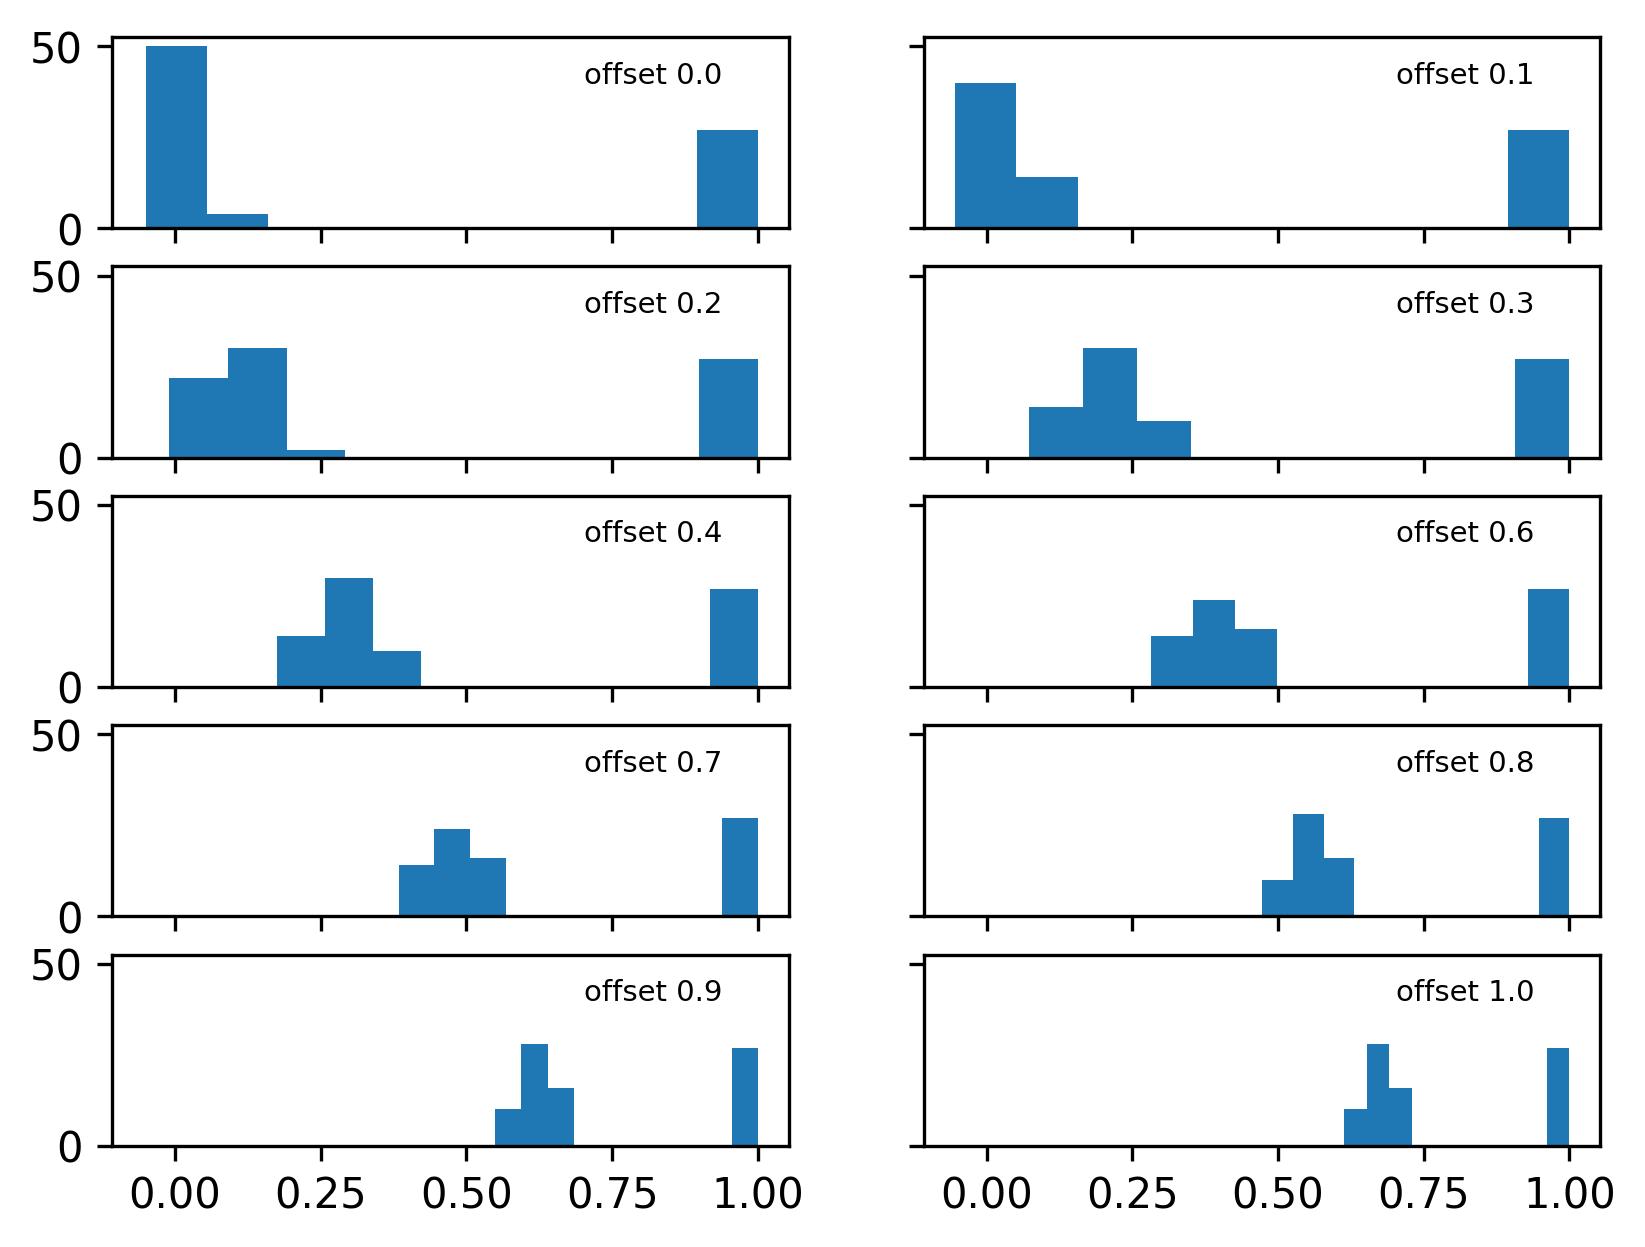

In [3]:
offsets = np.linspace(0, 1, 10)
fig, axs = plt.subplots(5, 2, dpi=300, sharex=True, sharey=True)
for idx, (offset, ax) in enumerate(zip(offsets, axs.flatten())):
    model = HierarchicalGratingModel(
        gratings=gratings,
        G_prob=G_prob,
        X_sigma=x_sigma,
        I_sigma=I_sigma,
        gratings_offset=offset
    )
    ax.hist(model.G_X_mapping.flatten(), bins=10)
    # write the offset value on the plot
    ax.text(0.8, 0.8, f'offset {offset:.1f}', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=7)

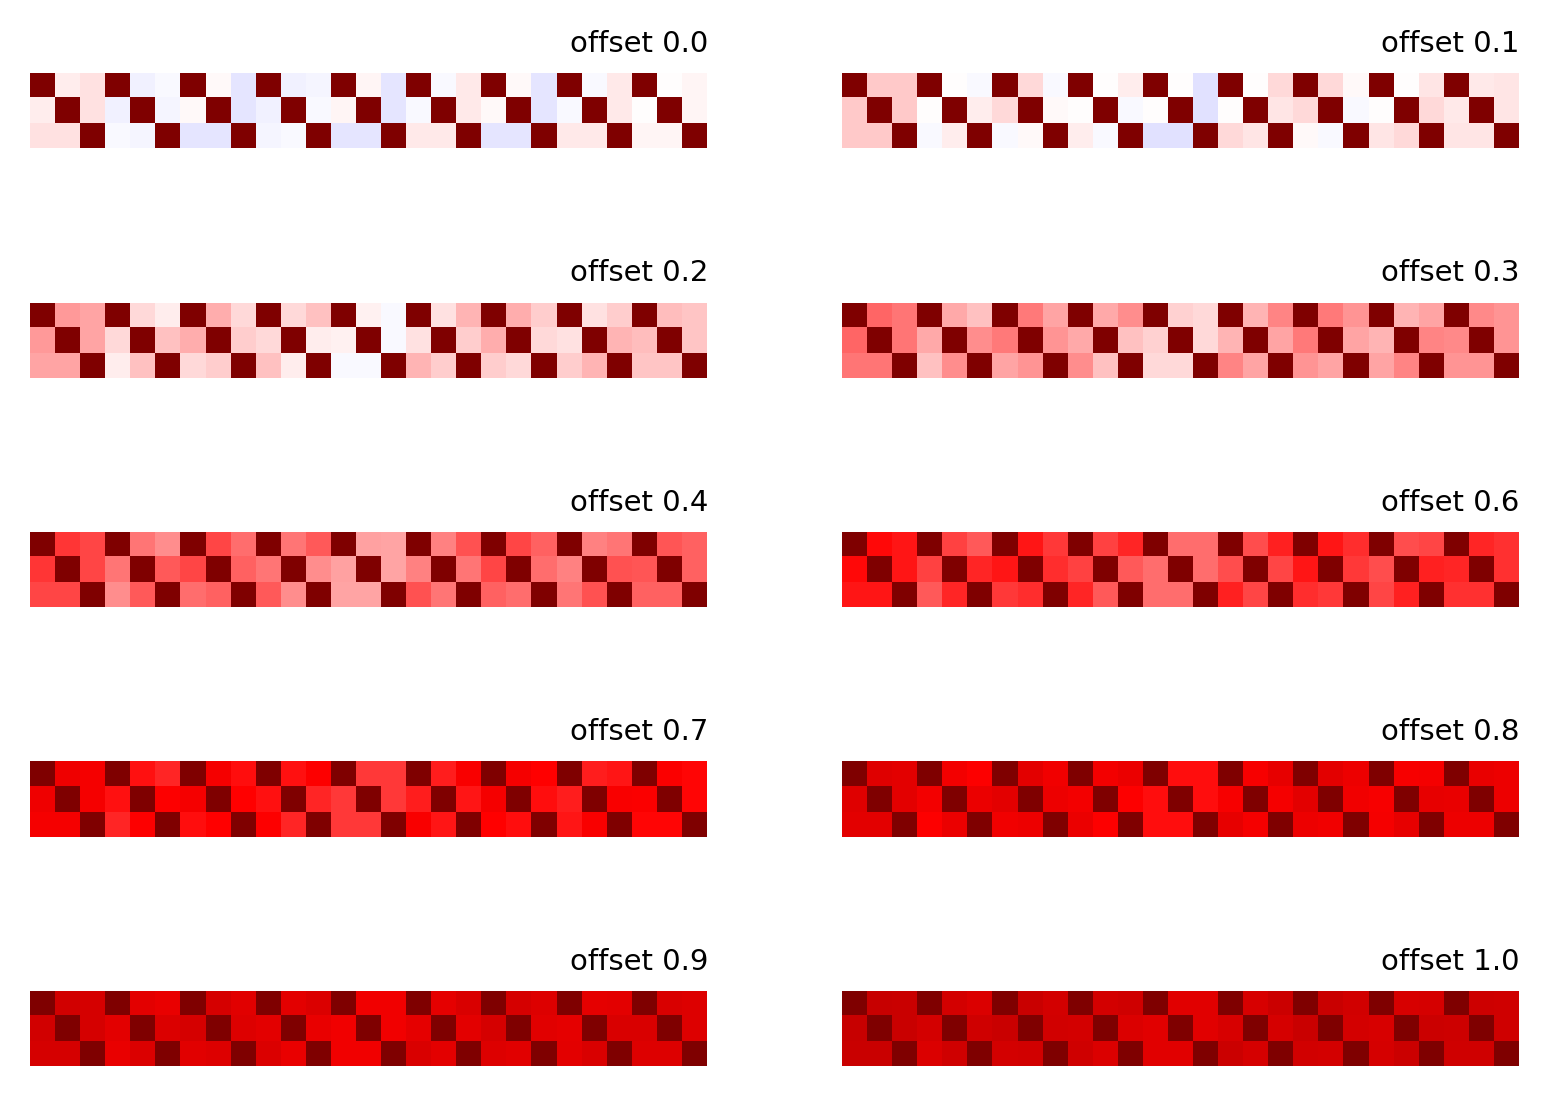

In [9]:
offsets = np.linspace(0, 1, 10)
fig, axs = plt.subplots(5, 2, dpi=300, sharex=True, sharey=True)
for idx, (offset, ax) in enumerate(zip(offsets, axs.flatten())):
    model = HierarchicalGratingModel(
        gratings=gratings,
        G_prob=G_prob,
        X_sigma=x_sigma,
        I_sigma=I_sigma,
        gratings_offset=offset
    )
    ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
    ax.axis('off')
    # write the offset value on the plot
    ax.text(0.9, 1.4, f'offset {offset:.1f}', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=7)

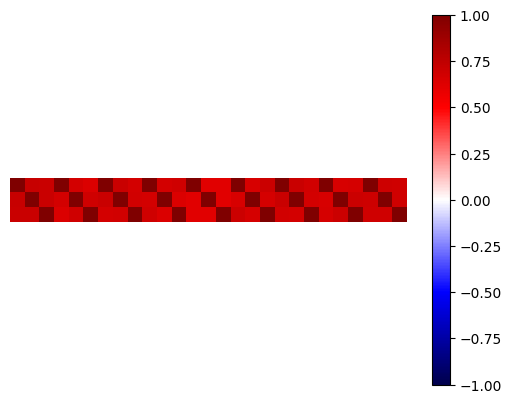

In [5]:

plt.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
plt.axis("off")
plt.colorbar()